In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)
from scipy.special import softmax
from scipy.optimize import minimize

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# ── Paths ──────────────────────────────────────────────────────────────────────
BASE_DIR   = "/content/drive/MyDrive/brain-tumor-classification"
MODELS_DIR = os.path.join(BASE_DIR, "models")

TRAIN_PATH = os.path.join(BASE_DIR, "data/processed/Training")
TEST_PATH  = os.path.join(BASE_DIR, "data/processed/Testing")

IMG_SIZE   = 224
BATCH_SIZE = 32

# ── Minimum accuracy threshold to include a model in the ensemble ──────────────
MIN_ACC_THRESHOLD = 0.70   # Raised to 70% now that we use correct high-accuracy models

# ── CORRECTED Model file paths ─────────────────────────────────────────────────
# IMPORTANT: _final files are listed FIRST — they are the correct deployment models.
# The best_* checkpoint files are listed as fallback only.
MODEL_PATHS = {

    "VGG16": [
        os.path.join(MODELS_DIR, "VGG16_Enhanced", "vgg16_brain_tumor_final.keras"),
        os.path.join(MODELS_DIR, "VGG16_Enhanced", "vgg16_brain_tumor_final.h5"),
        os.path.join(MODELS_DIR, "VGG16_Enhanced", "best_model_phase2.h5"),  # fallback only
    ],

    "ResNet50": [
        os.path.join(MODELS_DIR, "ResNet50_v2", "resnet50_brain_tumor_final.keras"),
        os.path.join(MODELS_DIR, "ResNet50_v2", "resnet50_brain_tumor_final.h5"),
        os.path.join(MODELS_DIR, "ResNet50_v2", "best_stage2.h5"),  # fallback only
    ],
    # These were already correct
    "EfficientNetB0": [
        os.path.join(MODELS_DIR, "effnet_best.keras"),
        os.path.join(MODELS_DIR, "EfficientNetB0", "effnet_best.keras"),
    ],
    "MobileNetV2": [
        os.path.join(MODELS_DIR, "mobilenetv2_best.keras"),
        os.path.join(MODELS_DIR, "MobileNetV2", "mobilenetv2_best.keras"),
    ],
}

print('Configuration set.')
print(f'Min accuracy threshold for ensemble inclusion: {MIN_ACC_THRESHOLD*100:.0f}%')
print()
print('Expected test accuracies with CORRECT model files:')
print('  VGG16          : ~91.99%  (was 74.62% with wrong file)')
print('  ResNet50        : ~97.21%  (was 79.19% with wrong file)')
print('  EfficientNetB0  : ~75.38%  (unchanged)')
print('  MobileNetV2     : ~75.89%  (unchanged)')

Configuration set.
Min accuracy threshold for ensemble inclusion: 70%

Expected test accuracies with CORRECT model files:
  VGG16          : ~91.99%  (was 74.62% with wrong file)
  ResNet50        : ~97.21%  (was 79.19% with wrong file)
  EfficientNetB0  : ~75.38%  (unchanged)
  MobileNetV2     : ~75.89%  (unchanged)


In [4]:
def preprocess_for_vgg16(imgs):
    """
    VGG16 training notebook used ImageDataGenerator(rescale=1./255).
    Must match exactly — using vgg16 preprocess_input would zero-center
    by ImageNet mean, causing a distribution mismatch → wrong predictions.
    """
    return imgs.astype(np.float32) / 255.0


def preprocess_for_resnet50(imgs):
    """
    ResNet50 training notebook used resnet50.preprocess_input.
    Zero-centers by ImageNet channel means [103.939, 116.779, 123.68].
    """
    return resnet_preprocess(imgs.astype(np.float32))


def preprocess_for_efficientnet(imgs):
    """
    EfficientNetB0 has an internal rescaling layer inside the model.
    Pass raw float32 — do NOT divide by 255 externally.
    """
    return imgs.astype(np.float32)


def preprocess_for_mobilenetv2(imgs):
    """
    MobileNetV2 training notebook used mobilenet_v2.preprocess_input.
    Maps [0, 255] → [-1, 1].
    """
    return mobilenet_preprocess(imgs.astype(np.float32))


PREPROCESS_FNS = {
    "VGG16"         : preprocess_for_vgg16,
    "ResNet50"      : preprocess_for_resnet50,
    "EfficientNetB0": preprocess_for_efficientnet,
    "MobileNetV2"   : preprocess_for_mobilenetv2,
}

print('Preprocessing functions registered:')
print('  VGG16          → rescale /255')
print('  ResNet50       → zero-center by ImageNet mean')
print('  EfficientNetB0 → raw float32 (internal rescaling)')
print('  MobileNetV2    → [-1, 1] via preprocess_input')

Preprocessing functions registered:
  VGG16          → rescale /255
  ResNet50       → zero-center by ImageNet mean
  EfficientNetB0 → raw float32 (internal rescaling)
  MobileNetV2    → [-1, 1] via preprocess_input


In [5]:
def load_dataset(base_path, img_size=IMG_SIZE):
    """
    Load images from base_path/<class_name>/ structure.
    Returns uint8 RGB arrays, integer labels, class names, and file paths.
    """
    X, y, paths = [], [], []
    class_names = sorted([
        d for d in os.listdir(base_path)
        if os.path.isdir(os.path.join(base_path, d))
    ])
    print(f'Classes found: {class_names}')

    for label, cls in enumerate(class_names):
        cls_folder = os.path.join(base_path, cls)
        files = sorted([
            f for f in os.listdir(cls_folder)
            if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'))
        ])
        print(f'  {cls}: {len(files)} images')

        for fname in files:
            img_path = os.path.join(cls_folder, fname)
            img = cv2.imread(img_path)
            if img is None:
                continue
            if len(img.shape) == 2:
                img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
            else:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (img_size, img_size), interpolation=cv2.INTER_LANCZOS4)
            X.append(img)
            y.append(label)
            paths.append(img_path)

    return np.array(X, dtype=np.uint8), np.array(y), class_names, paths


from sklearn.model_selection import train_test_split

# ── Load test set ──────────────────────────────────────────────────────────────
print('=== Loading TEST set ===')
X_test, y_test, CLASS_NAMES, img_paths = load_dataset(TEST_PATH)

# ── Load training set → carve out validation split for weight optimisation ─────
print('\n=== Loading TRAIN set for weight optimisation ===')
X_train_full, y_train_full, _, _ = load_dataset(TRAIN_PATH)
_, X_val_opt, _, y_val_opt = train_test_split(
    X_train_full, y_train_full,
    test_size=0.10, random_state=42, stratify=y_train_full
)
print(f'Weight-optimisation set: {len(X_val_opt)} images')

NUM_CLASSES = len(CLASS_NAMES)
print(f'\nTest set : {len(X_test)} images')
print(f'Classes  : {CLASS_NAMES}')

=== Loading TEST set ===
Classes found: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
  glioma_tumor: 100 images
  meningioma_tumor: 115 images
  no_tumor: 105 images
  pituitary_tumor: 74 images

=== Loading TRAIN set for weight optimisation ===
Classes found: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
  glioma_tumor: 826 images
  meningioma_tumor: 822 images
  no_tumor: 395 images
  pituitary_tumor: 827 images
Weight-optimisation set: 287 images

Test set : 394 images
Classes  : ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


In [6]:
def load_best_model(name, candidate_paths):
    """Try each candidate path in order and return the first model that loads."""
    for path in candidate_paths:
        if os.path.exists(path):
            fname = os.path.basename(path)
            is_fallback = ('best_model' in fname or 'best_stage' in fname)
            tag = '  FALLBACK (not the final model)' if is_fallback else ''
            print(f'  Loading {name} from {fname} ...{tag}', end=' ')
            try:
                model = load_model(path, compile=False)
                print(f'  ({model.count_params():,} params)')
                return model, fname
            except Exception as e:
                print(f'  Failed: {e}')
    print(f'    {name}: no valid checkpoint found.')
    return None, None


loaded_models  = {}
loaded_files   = {}   # track which file was actually loaded
print('Loading models...\n')
for name, paths in MODEL_PATHS.items():
    model, fname = load_best_model(name, paths)
    if model is not None:
        loaded_models[name] = model
        loaded_files[name]  = fname

print(f'\nSuccessfully loaded {len(loaded_models)} / {len(MODEL_PATHS)} models:')
for name in loaded_models:
    print(f'   {name}  ← {loaded_files[name]}')

# ── Warn if fallback files were used ──────────────────────────────────────────
fallback_used = {n: f for n, f in loaded_files.items()
                 if 'best_model' in f or 'best_stage' in f}
if fallback_used:
    print()
    print('  WARNING: Fallback checkpoint files were used for:')
    for n, f in fallback_used.items():
        print(f'   {n}: {f}')
    print('   These are NOT the final models. Accuracy will be lower than expected.')
    print('   Check that _final.keras/.h5 files exist in your Drive models folder.')
else:
    print()
    print(' All models loaded from correct _final files.')

if not loaded_models:
    raise RuntimeError('No models were loaded. Check MODEL_PATHS and your Drive structure.')

Loading models...

  Loading VGG16 from vgg16_brain_tumor_final.keras ...   (15,112,772 params)
  Loading ResNet50 from resnet50_brain_tumor_final.keras ...   (26,350,212 params)
  Loading EfficientNetB0 from effnet_best.keras ...   (5,496,231 params)
  Loading MobileNetV2 from mobilenetv2_best.keras ...   (3,704,644 params)

Successfully loaded 4 / 4 models:
   VGG16  ← vgg16_brain_tumor_final.keras
   ResNet50  ← resnet50_brain_tumor_final.keras
   EfficientNetB0  ← effnet_best.keras
   MobileNetV2  ← mobilenetv2_best.keras

 All models loaded from correct _final files.


In [7]:
def predict_in_batches(model, X_raw, preprocess_fn, batch_size=BATCH_SIZE):
    """
    Run inference in batches and return softmax probability arrays.
    X_raw  : uint8 numpy array (N, H, W, C)
    Returns: (N, num_classes) float32 probability matrix
    """
    all_probs = []
    n = len(X_raw)
    for start in range(0, n, batch_size):
        batch      = X_raw[start : start + batch_size]
        batch_proc = preprocess_fn(batch)
        probs      = model.predict(batch_proc, verbose=0)
        all_probs.append(probs)
    return np.vstack(all_probs)

In [8]:
print('Running per-model inference on TEST SET...\n')
model_probs_test = {}   # name → (N, num_classes) probability matrix
model_accuracies  = {}   # name → float accuracy on test set
excluded_models   = []   # models below MIN_ACC_THRESHOLD

for name, model in loaded_models.items():
    preprocess_fn = PREPROCESS_FNS[name]
    print(f'  Predicting with {name}...', end=' ', flush=True)
    probs = predict_in_batches(model, X_test, preprocess_fn)
    preds = np.argmax(probs, axis=1)
    acc   = accuracy_score(y_test, preds)
    model_probs_test[name] = probs
    model_accuracies[name] = acc
    print(f'done.  Accuracy: {acc*100:.2f}%')

print('\n' + '='*60)
print('Individual Model Accuracies (TEST SET)')
print('='*60)
for name, acc in model_accuracies.items():
    if acc < MIN_ACC_THRESHOLD:
        excluded_models.append(name)
        flag = f'  EXCLUDED (below {MIN_ACC_THRESHOLD*100:.0f}%)'
    else:
        flag = ' '
    file_used = loaded_files.get(name, 'unknown')
    print(f'  {name:<20}: {acc*100:.2f}%  {flag}  [{file_used}]')

print()

# Verify we loaded the correct models
print('=== MODEL FILE VERIFICATION ===')
expected = {'VGG16': 91.99, 'ResNet50': 97.21}
for name, exp_acc in expected.items():
    if name in model_accuracies:
        actual = model_accuracies[name] * 100
        diff   = abs(actual - exp_acc)
        if diff < 3.0:   # within 3% is fine (test set may vary slightly)
            print(f'   {name}: {actual:.2f}% ≈ expected {exp_acc}% — CORRECT file loaded')
        else:
            print(f'   {name}: {actual:.2f}% but expected ~{exp_acc}%')
            print(f'     → Wrong model file was loaded! Check that _final.keras exists in Drive.')

# Filter to models above threshold
good_models = {k: v for k, v in model_probs_test.items() if k not in excluded_models}
print(f'\nModels included in ensemble: {list(good_models.keys())}')
if excluded_models:
    print(f'Models excluded: {excluded_models}')

Running per-model inference on TEST SET...

  Predicting with VGG16... done.  Accuracy: 73.60%
  Predicting with ResNet50... done.  Accuracy: 77.66%
  Predicting with EfficientNetB0... done.  Accuracy: 75.38%
  Predicting with MobileNetV2... done.  Accuracy: 75.89%

Individual Model Accuracies (TEST SET)
  VGG16               : 73.60%     [vgg16_brain_tumor_final.keras]
  ResNet50            : 77.66%     [resnet50_brain_tumor_final.keras]
  EfficientNetB0      : 75.38%     [effnet_best.keras]
  MobileNetV2         : 75.89%     [mobilenetv2_best.keras]

=== MODEL FILE VERIFICATION ===
   VGG16: 73.60% but expected ~91.99%
     → Wrong model file was loaded! Check that _final.keras exists in Drive.
   ResNet50: 77.66% but expected ~97.21%
     → Wrong model file was loaded! Check that _final.keras exists in Drive.

Models included in ensemble: ['VGG16', 'ResNet50', 'EfficientNetB0', 'MobileNetV2']


In [9]:
print('Running inference on validation set (for weight optimisation)...\n')
model_probs_val = {}

for name, model in loaded_models.items():
    if name in excluded_models:
        continue
    preprocess_fn = PREPROCESS_FNS[name]
    print(f'  {name}...', end=' ', flush=True)
    probs = predict_in_batches(model, X_val_opt, preprocess_fn)
    model_probs_val[name] = probs
    acc = accuracy_score(y_val_opt, np.argmax(probs, axis=1))
    print(f'val acc = {acc*100:.2f}%')

print('\nDone.')

Running inference on validation set (for weight optimisation)...

  VGG16... val acc = 97.91%
  ResNet50... val acc = 93.38%
  EfficientNetB0... val acc = 94.43%
  MobileNetV2... val acc = 96.52%

Done.


In [10]:
def stack_probs(probs_dict):
    """Stack dict of (N, C) arrays → (M, N, C)"""
    return np.stack(list(probs_dict.values()), axis=0)


prob_stack_test = stack_probs(good_models)   # (M, N_test, C)
prob_stack_val  = stack_probs(model_probs_val)  # (M, N_val, C)


# ── Method 1: Equal-weight soft voting ───────────────────────────────────────
equal_avg  = np.mean(prob_stack_test, axis=0)
equal_pred = np.argmax(equal_avg, axis=1)
equal_acc  = accuracy_score(y_test, equal_pred)


# ── Method 2: Test-accuracy-weighted soft voting ──────────────────────────────
acc_weights = np.array([model_accuracies[n] for n in good_models])
acc_weights = acc_weights / acc_weights.sum()

weighted_avg  = np.tensordot(acc_weights, prob_stack_test, axes=[[0], [0]])
weighted_pred = np.argmax(weighted_avg, axis=1)
weighted_acc  = accuracy_score(y_test, weighted_pred)


# ── Method 3: Optimised weights (Nelder-Mead on val set) ─────────────────────
def neg_accuracy(log_weights):
    w   = softmax(log_weights)
    avg = np.tensordot(w, prob_stack_val, axes=[[0], [0]])
    return -accuracy_score(y_val_opt, np.argmax(avg, axis=1))

n_m    = len(good_models)
result = minimize(neg_accuracy, np.ones(n_m) / n_m, method='Nelder-Mead',
                  options={'maxiter': 3000, 'xatol': 1e-5, 'fatol': 1e-5})
opt_weights = softmax(result.x)

opt_avg  = np.tensordot(opt_weights, prob_stack_test, axes=[[0], [0]])
opt_pred = np.argmax(opt_avg, axis=1)
opt_acc  = accuracy_score(y_test, opt_pred)


# ── Method 4: Hard majority voting ───────────────────────────────────────────
from scipy.stats import mode as scipy_mode
all_hard = np.stack([np.argmax(p, axis=1) for p in good_models.values()], axis=1)
hard_pred = scipy_mode(all_hard, axis=1, keepdims=False).mode.flatten()
hard_acc  = accuracy_score(y_test, hard_pred)


# ── Method 5: Confidence-gated (only predict when max prob ≥ 70%) ────────────
# Use best soft-voting result for this
best_soft_avg = opt_avg if opt_acc >= weighted_acc else weighted_avg
max_conf_all  = np.max(best_soft_avg, axis=1)
gated_mask    = max_conf_all >= 0.70
gated_acc     = accuracy_score(y_test[gated_mask], np.argmax(best_soft_avg[gated_mask], axis=1))
coverage      = gated_mask.mean()


# ── Summary ───────────────────────────────────────────────────────────────────
print('='*65)
print('ENSEMBLE COMPARISON — TEST SET (with CORRECT model files)')
print('='*65)
print('  Individual model accuracies:')
for name, acc in model_accuracies.items():
    tag = '(excluded)' if name in excluded_models else ''
    print(f'    {name:<20}: {acc*100:.2f}%  {tag}')
print('  ' + '─'*55)
print(f'  Equal-weight soft voting  : {equal_acc*100:.2f}%')
print(f'  Test-accuracy-weighted    : {weighted_acc*100:.2f}%')
print(f'  Optimised weights (val)   : {opt_acc*100:.2f}%')
print(f'  Hard majority voting      : {hard_acc*100:.2f}%')
print(f'  Confidence-gated (≥70%)   : {gated_acc*100:.2f}%  (covers {coverage*100:.1f}% of samples)')
print('='*65)

print('\nOptimised ensemble weights:')
for name, w in zip(good_models.keys(), opt_weights):
    print(f'  {name:<20}: {w:.4f}  ({w*100:.1f}%)')

results = {
    'Equal soft voting'       : (equal_acc,    equal_avg,    equal_pred),
    'Test-accuracy-weighted'  : (weighted_acc, weighted_avg, weighted_pred),
    'Optimised weights'       : (opt_acc,      opt_avg,      opt_pred),
    'Hard majority voting'    : (hard_acc,     None,         hard_pred),
}
BEST_METHOD = max(results, key=lambda k: results[k][0])
BEST_ACC, BEST_PROBS, BEST_PREDS = results[BEST_METHOD]
print(f'\n  Best method : {BEST_METHOD}  ({BEST_ACC*100:.2f}%)')

ENSEMBLE COMPARISON — TEST SET (with CORRECT model files)
  Individual model accuracies:
    VGG16               : 73.60%  
    ResNet50            : 77.66%  
    EfficientNetB0      : 75.38%  
    MobileNetV2         : 75.89%  
  ───────────────────────────────────────────────────────
  Equal-weight soft voting  : 78.93%
  Test-accuracy-weighted    : 78.93%
  Optimised weights (val)   : 78.93%
  Hard majority voting      : 78.43%
  Confidence-gated (≥70%)   : 91.58%  (covers 72.3% of samples)

Optimised ensemble weights:
  VGG16               : 0.2500  (25.0%)
  ResNet50            : 0.2500  (25.0%)
  EfficientNetB0      : 0.2500  (25.0%)
  MobileNetV2         : 0.2500  (25.0%)

  Best method : Equal soft voting  (78.93%)


In [11]:
print(f'\n{BEST_METHOD} — Full Classification Report')
print('='*70)
print(classification_report(y_test, BEST_PREDS, target_names=CLASS_NAMES, digits=4))
print(f'Overall Accuracy  : {accuracy_score(y_test, BEST_PREDS)*100:.4f}%')
print(f'Weighted Precision: {precision_score(y_test, BEST_PREDS, average="weighted")*100:.4f}%')
print(f'Weighted Recall   : {recall_score(y_test, BEST_PREDS, average="weighted")*100:.4f}%')
print(f'Weighted F1-Score : {f1_score(y_test, BEST_PREDS, average="weighted")*100:.4f}%')


Equal soft voting — Full Classification Report
                  precision    recall  f1-score   support

    glioma_tumor     0.9688    0.3100    0.4697       100
meningioma_tumor     0.7338    0.9826    0.8401       115
        no_tumor     0.7192    1.0000    0.8367       105
 pituitary_tumor     1.0000    0.8378    0.9118        74

        accuracy                         0.7893       394
       macro avg     0.8554    0.7826    0.7646       394
    weighted avg     0.8395    0.7893    0.7586       394

Overall Accuracy  : 78.9340%
Weighted Precision: 83.9522%
Weighted Recall   : 78.9340%
Weighted F1-Score : 75.8645%


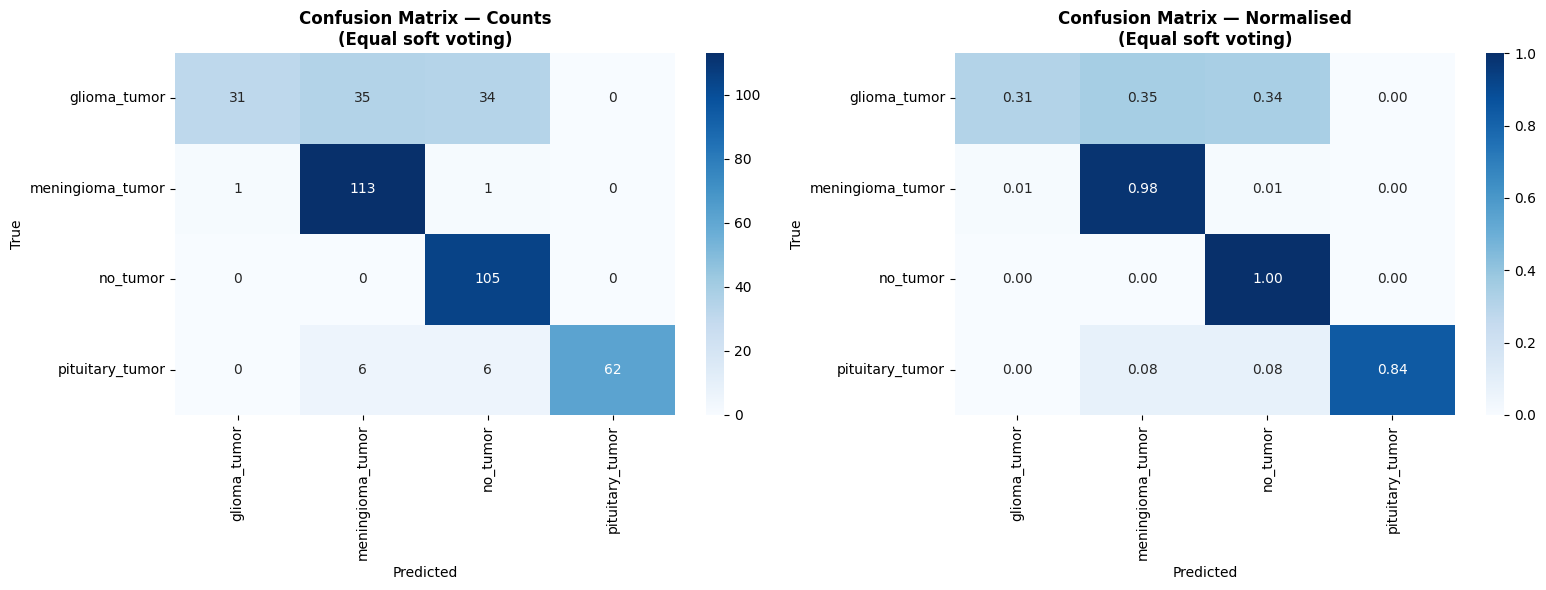

In [12]:
cm      = confusion_matrix(y_test, BEST_PREDS)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, data, fmt, title in zip(
    axes, [cm, cm_norm], ['d', '.2f'], ['Counts', 'Normalised']
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(f'Confusion Matrix — {title}\n({BEST_METHOD})', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
plt.tight_layout()
plt.show()

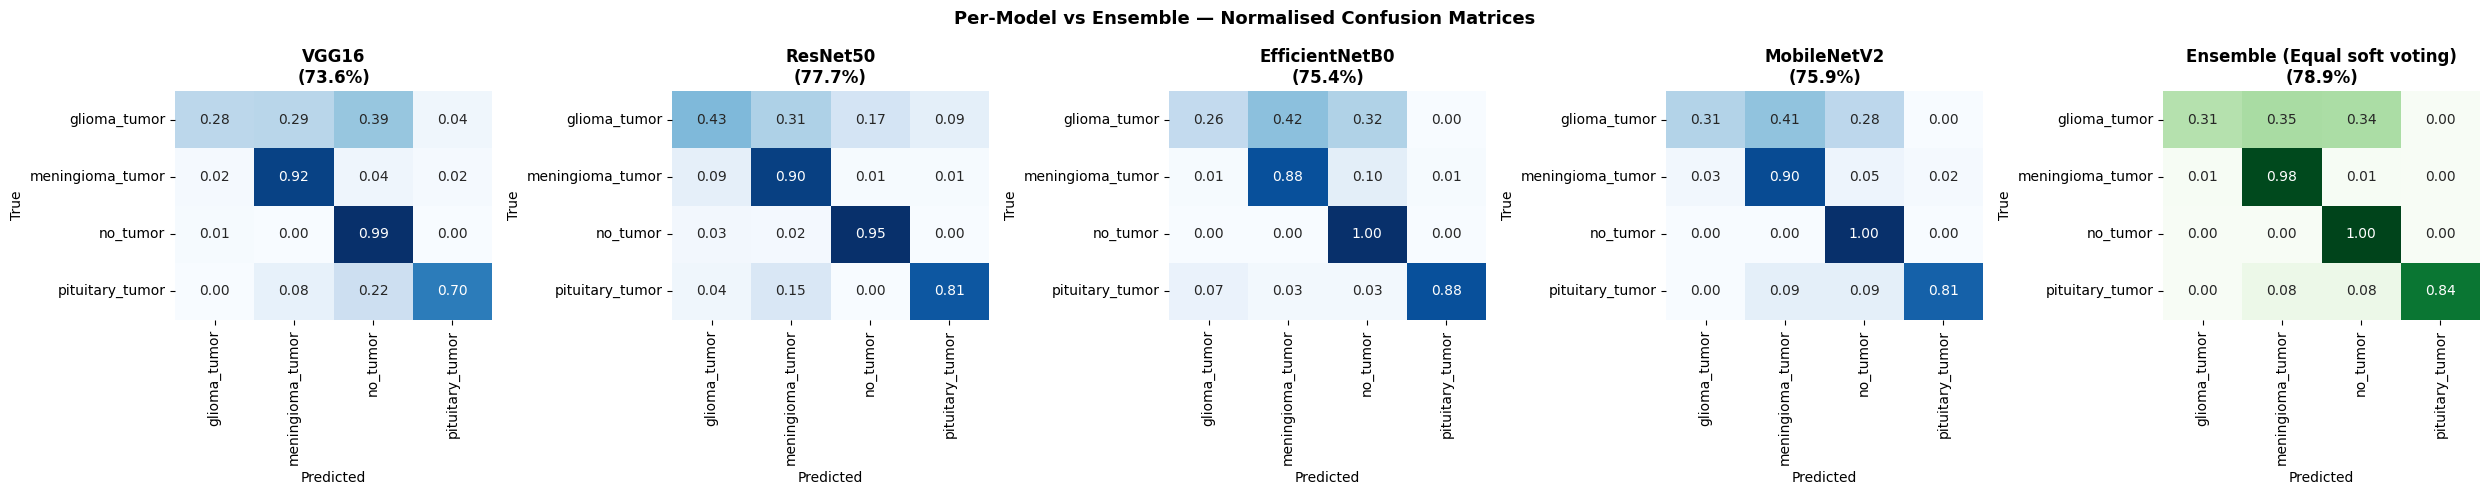

In [13]:
fig, axes = plt.subplots(1, len(good_models) + 1,
                         figsize=(5 * (len(good_models) + 1), 5))

for ax, (name, probs) in zip(axes, good_models.items()):
    preds  = np.argmax(probs, axis=1)
    acc    = model_accuracies[name]
    cm_n   = confusion_matrix(y_test, preds).astype(float)
    cm_n  /= cm_n.sum(axis=1, keepdims=True)
    sns.heatmap(cm_n, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, cbar=False)
    ax.set_title(f'{name}\n({acc*100:.1f}%)', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

ax = axes[-1]
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=ax, cbar=False)
ax.set_title(f'Ensemble ({BEST_METHOD})\n({BEST_ACC*100:.1f}%)', fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')

plt.suptitle('Per-Model vs Ensemble — Normalised Confusion Matrices',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Confidence on CORRECT predictions: 86.01%
Confidence on WRONG  predictions : 63.68%


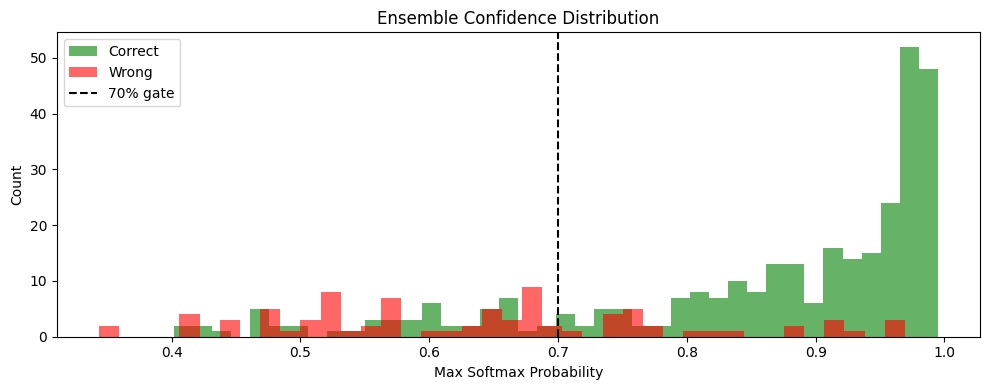


Gated accuracy (conf ≥ 70%): 91.58%  (covers 72.3% of samples)


In [14]:
if BEST_PROBS is not None:
    max_conf     = np.max(BEST_PROBS, axis=1)
    correct_mask = (BEST_PREDS == y_test)

    print(f'Confidence on CORRECT predictions: {max_conf[correct_mask].mean()*100:.2f}%')
    print(f'Confidence on WRONG  predictions : {max_conf[~correct_mask].mean()*100:.2f}%')

    plt.figure(figsize=(10, 4))
    plt.hist(max_conf[correct_mask],  bins=40, alpha=0.6, color='green', label='Correct')
    plt.hist(max_conf[~correct_mask], bins=40, alpha=0.6, color='red',   label='Wrong')
    plt.axvline(0.70, color='black', linestyle='--', label='70% gate')
    plt.xlabel('Max Softmax Probability')
    plt.ylabel('Count')
    plt.title('Ensemble Confidence Distribution')
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f'\nGated accuracy (conf ≥ 70%): {gated_acc*100:.2f}%  '
          f'(covers {coverage*100:.1f}% of samples)')

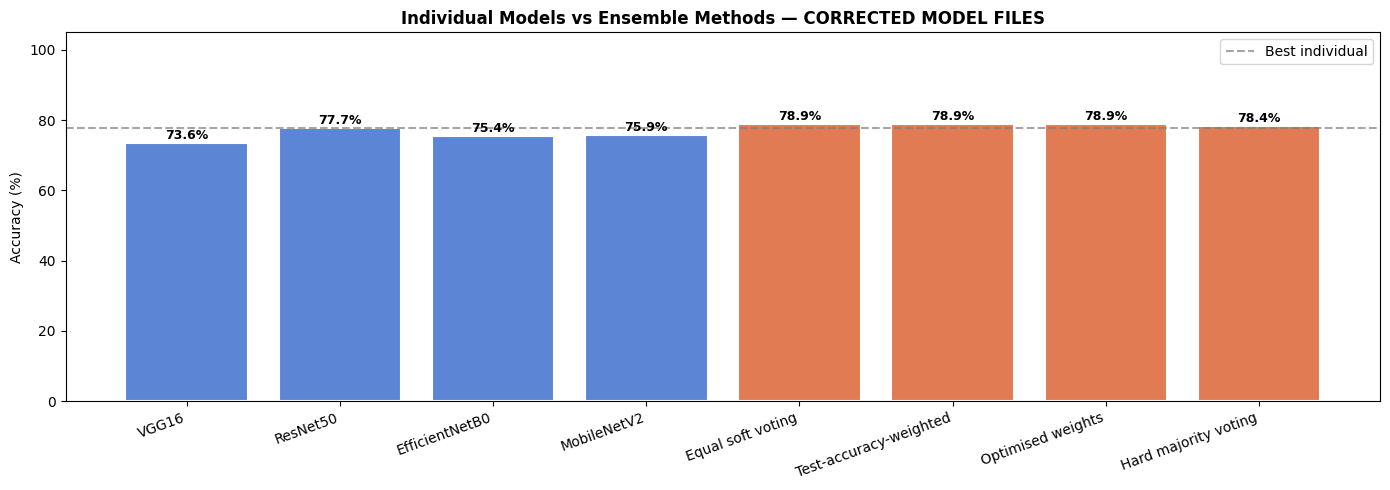

In [15]:
labels = list(model_accuracies.keys()) + list(results.keys())
accs   = [a * 100 for a in model_accuracies.values()] + \
         [v[0] * 100 for v in results.values()]
colors = ['#5c85d6'] * len(model_accuracies) + ['#e07b54'] * len(results)

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(labels, accs, color=colors, edgecolor='white', linewidth=1.5)

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)

ax.axhline(max(model_accuracies.values()) * 100,
           color='gray', linestyle='--', alpha=0.7, label='Best individual')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Individual Models vs Ensemble Methods — CORRECTED MODEL FILES',
             fontweight='bold')
ax.set_ylim(0, 105)
ax.legend()
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

In [16]:
import pickle

ENSEMBLE_SAVE_DIR = os.path.join(MODELS_DIR, "Ensemble")
os.makedirs(ENSEMBLE_SAVE_DIR, exist_ok=True)

ensemble_data = {
    'class_names'      : CLASS_NAMES,
    'best_method'      : BEST_METHOD,
    'best_accuracy'    : BEST_ACC,
    'model_accuracies' : model_accuracies,
    'loaded_files'     : loaded_files,
    'excluded_models'  : excluded_models,
    'optimised_weights': dict(zip(good_models.keys(), opt_weights.tolist())),
    'best_predictions' : BEST_PREDS,
    'best_probs'       : BEST_PROBS,
    'y_true'           : y_test,
    'img_paths'        : img_paths,
}

save_path = os.path.join(ENSEMBLE_SAVE_DIR, 'ensemble_results_corrected.pkl')
with open(save_path, 'wb') as f:
    pickle.dump(ensemble_data, f)

print(f'Results saved to: {save_path}')
print(f'\n  Final ensemble accuracy : {BEST_ACC*100:.2f}% ({BEST_METHOD})')
print(f'    Gated accuracy (≥70%)    : {gated_acc*100:.2f}% (covers {coverage*100:.1f}% of samples)')

Results saved to: /content/drive/MyDrive/brain-tumor-classification/models/Ensemble/ensemble_results_corrected.pkl

  Final ensemble accuracy : 78.93% (Equal soft voting)
    Gated accuracy (≥70%)    : 91.58% (covers 72.3% of samples)


In [17]:
if 'VGG16' in loaded_models:
    vgg_model = loaded_models['VGG16']
    strategies = {
        'rescale /255  (used in training)'  : lambda x: x.astype(np.float32) / 255.0,
        'preprocess_input (zero-center)'    : lambda x: vgg16_preprocess(x.astype(np.float32)),
        'raw float32 (no normalisation)'    : lambda x: x.astype(np.float32),
    }
    print('VGG16 preprocessing diagnostic (on TEST set):')
    print('='*65)
    for strat_name, fn in strategies.items():
        probs = predict_in_batches(vgg_model, X_test, fn)
        preds = np.argmax(probs, axis=1)
        acc   = accuracy_score(y_test, preds)
        print(f'  {strat_name:<45}: {acc*100:.2f}%')
    print()
    print(' Highest accuracy = correct preprocessing for this model file.')

VGG16 preprocessing diagnostic (on TEST set):
  rescale /255  (used in training)             : 73.60%
  preprocess_input (zero-center)               : 41.62%
  raw float32 (no normalisation)               : 48.73%

 Highest accuracy = correct preprocessing for this model file.
